In [117]:


import numpy as np
import pandas as pd

import shap

import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split
)

from sklearn.ensemble import (
    RandomForestRegressor
)

## Feature Preparation

In [123]:
def prepare_reliability_features(df):

    df = df.copy()

    temperature_kelvin = (
        df["Stress_Temperature_C"]
        + 273.15
    )

    df["Inverse_Temperature"] = (
        1 / temperature_kelvin
    )

    df["Log_Voltage"] = np.log(
        df["Stress_Voltage_V"].clip(lower=1.0)
    )

    df["Humidity_Fraction"] = (
        df["Humidity_Percent"] / 100
    )

    return df

## Training Dataset

In [128]:
def create_training_dataset(df):

    df = prepare_reliability_features(df)

    failure_data = df[
        df["Censored"] == 0
    ].copy()

    X = failure_data[
        [
            "Inverse_Temperature",
            "Log_Voltage",
            "Humidity_Fraction"
        ]
    ]

    y = np.log(
        failure_data[
            "Failure_Time_Hours"
        ]
    )

    return train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42
    )

## Train Best Model

In [132]:
def train_explainable_model(df):

    (
        X_train,
        X_test,
        y_train,
        y_test
    ) = create_training_dataset(df)

    model = RandomForestRegressor(
        n_estimators=300,
        max_depth=8,
        random_state=42
    )

    model.fit(
        X_train,
        y_train
    )

    return (
        model,
        X_train,
        X_test
    )

## Feature Importance Engine

In [135]:
def feature_importance_analysis(
    model,
    X_train
):

    importance = (
        model.feature_importances_
    )

    feature_importance = (
        pd.DataFrame(
            {
                "Feature":
                X_train.columns,

                "Importance":
                importance
            }
        )
        .sort_values(
            by="Importance",
            ascending=False
        )
    )

    feature_importance[
        "Importance_Percent"
    ] = (
        feature_importance[
            "Importance"
        ]
        /
        feature_importance[
            "Importance"
        ].sum()
        * 100
    )

    print(
        "\nFEATURE IMPORTANCE"
    )

    print(
        "-" * 50
    )

    print(
        feature_importance[
            [
                "Feature",
                "Importance_Percent"
            ]
        ]
    )

    return feature_importance

In [140]:
df = pd.read_csv(
    "reliability_dataset1.csv"
)

model, X_train, X_test = (
    train_explainable_model(df)
)

print(X_train.shape)

(6691, 3)


## SHAP Explainability

In [ ]:
def shap_analysis(
    model,
    X_train
):

    explainer = (
        shap.TreeExplainer(
            model
        )
    )

    shap_values = (
        explainer.shap_values(
            X_train
        )
    )

    shap.summary_plot(
        shap_values,
        X_train
    )

    return shap_values
 

(6691, 3)


## Reliability Driver Ranking

In [142]:
def identify_reliability_drivers(
    feature_importance
):

    print(
        "\nRELIABILITY DRIVER RANKING"
    )

    print(
        "-" * 50
    )

    rank = 1

    for _, row in (
        feature_importance
        .iterrows()
    ):

        print(
            f"{rank}. "
            f"{row['Feature']} "
            f"("
            f"{row['Importance_Percent']:.2f}%"
            f")"
        )

        rank += 1

## Engineering Interpretation

In [143]:
def engineering_interpretation(
    feature_importance
):

    top_feature = (
        feature_importance
        .iloc[0]["Feature"]
    )

    top_percent = (
        feature_importance
        .iloc[0][
            "Importance_Percent"
        ]
    )

    print(
        "\nENGINEERING INSIGHT"
    )

    print(
        "-" * 50
    )

    print(
        f"Most critical stress "
        f"factor : "
        f"{top_feature}"
    )

    print(
        f"Contribution : "
        f"{top_percent:.2f}%"
    )

    print(
        "\nThis parameter "
        "has the strongest "
        "influence on "
        "predicted lifetime."
    )

## Main Engine


FEATURE IMPORTANCE
--------------------------------------------------
               Feature  Importance_Percent
0  Inverse_Temperature           93.520057
1          Log_Voltage            6.406388
2    Humidity_Fraction            0.073554

RELIABILITY DRIVER RANKING
--------------------------------------------------
1. Inverse_Temperature (93.52%)
2. Log_Voltage (6.41%)
3. Humidity_Fraction (0.07%)

ENGINEERING INSIGHT
--------------------------------------------------
Most critical stress factor : Inverse_Temperature
Contribution : 93.52%

This parameter has the strongest influence on predicted lifetime.


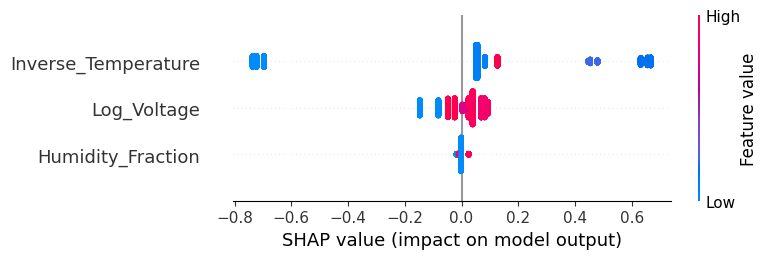

In [144]:
def run_explainable_ai_engine():

    df = pd.read_csv(
        "reliability_dataset1.csv"
    )

    (
        model,
        X_train,
        X_test
    ) = train_explainable_model(
        df
    )

    feature_importance = (
        feature_importance_analysis(
            model,
            X_train
        )
    )

    identify_reliability_drivers(
        feature_importance
    )

    engineering_interpretation(
        feature_importance
    )

    shap_analysis(
        model,
        X_train
    )


run_explainable_ai_engine()

